In [2]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt
import seaborn as sns
from gprofiler import GProfiler


In [3]:
GO_BP = pd.read_csv('data/gene_go_matrix_propT_rel-is_a-part_of_ont-BP.csv', index_col=0)
GO_CC = pd.read_csv('data/gene_go_matrix_propT_rel-is_a-part_of_ont-CC.csv', index_col=0)
GO_MF = pd.read_csv('data/gene_go_matrix_propT_rel-is_a-part_of_ont-MF.csv', index_col=0)
HPO   = pd.read_csv('data/gene_hpo_matrix_binary_withAncestors_namespace_Phenotypic abnormality.csv', index_col=0)

In [4]:
view1 = pd.read_csv('clusters/GO_BP-clusters.csv')
view2 = pd.read_csv('clusters/GO_MF-clusters.csv')
view3 = pd.read_csv('clusters/GO_CC-clusters.csv')
view4 = pd.read_csv('clusters/HPO-clusters.csv')
mofa = pd.read_csv('clusters/mofa-clusters.csv')

clusterings = {
    'GO_BP': view1,
    'GO_MF': view2,
    'GO_CC': view3,
    'HPO': view4,
    'MOFA': mofa
}

In [5]:
def build_coassignment_matrix(clusterings, views_to_include=None, ks_to_include=None):
    """
    Build the co-assignment matrix from multiple clusterings.

    Parameters
    ----------
    clusterings : dict
        {view_name: DataFrame with shape (n_samples, n_k)}
    views_to_include : list of str, optional
        Which views to include (default all)
    ks_to_include : list of int, optional
        Which k values to include (default all ks in clusterings)

    Returns
    -------
    coassign : np.ndarray, shape (n_samples, n_samples)
        Fraction of clusterings in which each pair of samples is in the same cluster
    """
    if views_to_include is None:
        views_to_include = list(clusterings.keys())

    # Determine ks
    if ks_to_include is None:
        # use all columns in first view
        ks_to_include = [int(c) for c in clusterings[views_to_include[0]].columns]

    n_samples = clusterings[views_to_include[0]].shape[0]
    coassign = np.zeros((n_samples, n_samples), dtype=float)
    n_total = 0

    for view in views_to_include:
        df = clusterings[view]
        for k in ks_to_include:
            labels = df[str(k)].values.ravel()
            # build co-assignment for this clustering
            for i in range(n_samples):
                for j in range(i, n_samples):
                    if labels[i] == labels[j]:
                        coassign[i, j] += 1
                        if i != j:
                            coassign[j, i] += 1
            n_total += 1

    coassign /= n_total
    return coassign


def consensus_clustering(coassign_matrix, n_clusters=10, method='average'):
    """
    Compute consensus clusters using hierarchical clustering.

    Parameters
    ----------
    coassign_matrix : np.ndarray
        n_samples x n_samples co-assignment matrix
    n_clusters : int
        Number of consensus clusters
    method : str
        Linkage method for hierarchical clustering (default 'average')

    Returns
    -------
    labels : np.ndarray, shape (n_samples,)
        Consensus cluster labels (1..n_clusters)
    """
    # Convert similarity to distance
    distance = 1.0 - coassign_matrix

    # Condensed distance matrix for linkage
    from scipy.spatial.distance import squareform
    dist_condensed = squareform(distance, checks=False)

    Z = linkage(dist_condensed, method=method)
    labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    return labels

Best number of clusters according to ΔCDF: 9


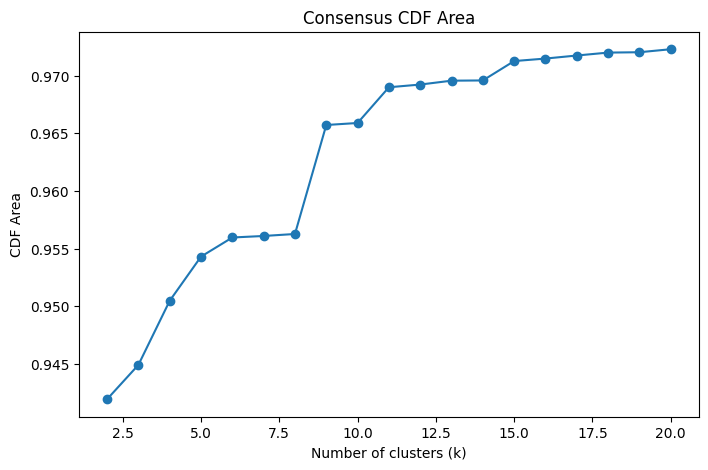

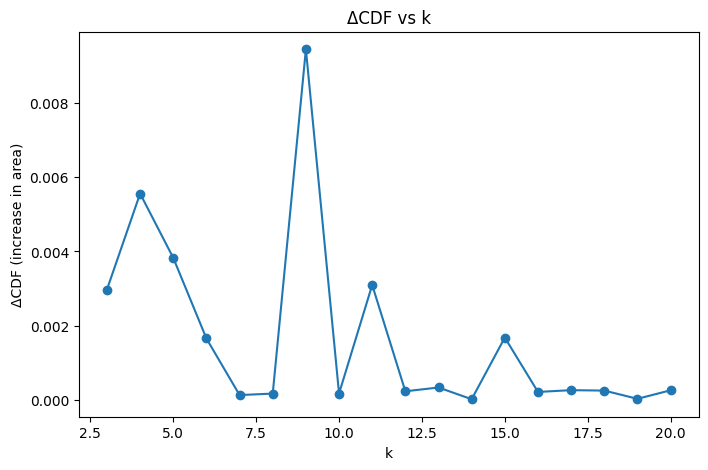

In [8]:
def consensus_cdf(consensus_matrix, bins=100):
    """
    Compute CDF of consensus values (upper triangle excluding diagonal).
    """
    vals = consensus_matrix[np.triu_indices_from(consensus_matrix, k=1)]
    hist, bin_edges = np.histogram(vals, bins=bins, range=(0,1), density=True)
    cdf = np.cumsum(hist) / np.sum(hist)
    return cdf, bin_edges[1:]  # cdf values and x-axis


def compute_cdf_scores(coassign_matrix, k_range):
    """
    For each k, compute:
      - consensus labels
      - within-cluster consensus scores
      - CDF area
    Returns dict of results.
    """
    results = {}
    distance = 1 - coassign_matrix

    for k in k_range:
        labels = consensus_clustering(coassign_matrix, n_clusters=k)

        # Build consensus matrix for clusters only
        n = len(labels)
        consensus_within = np.zeros((n, n))

        for i in range(n):
            for j in range(n):
                if labels[i] == labels[j]:
                    consensus_within[i, j] = coassign_matrix[i, j]

        # CDF of within-cluster agreement
        cdf, bins = consensus_cdf(consensus_within)
        auc = np.trapz(cdf, bins)   # area under CDF curve

        results[k] = {
            "labels": labels,
            "cdf": cdf,
            "bins": bins,
            "auc": auc,
        }

    return results


def find_optimal_k(cdf_results):
    """
    Choose optimal k using ΔCDF method.
    """
    ks = sorted(cdf_results.keys())
    aucs = [cdf_results[k]['auc'] for k in ks]

    deltas = np.diff(aucs)
    best_idx = np.argmax(deltas)  # biggest jump
    best_k = ks[best_idx + 1]     # delta is between k and k+1

    return best_k, ks, aucs, deltas

coassign = build_coassignment_matrix(clusterings,
                                     views_to_include=["HPO","GO_CC","GO_BP","GO_MF","MOFA"],
                                     ks_to_include=range(20,51))  # pick stable ks

k_range = range(2, 21)

cdf_results = compute_cdf_scores(coassign, k_range)
best_k, ks, aucs, deltas = find_optimal_k(cdf_results)

print("Best number of clusters according to ΔCDF:", best_k)

# Plot AUC
plt.figure(figsize=(8,5))
plt.plot(ks, aucs, "-o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("CDF Area")
plt.title("Consensus CDF Area")
plt.show()

# Plot ΔCDF
plt.figure(figsize=(8,5))
plt.plot(ks[1:], deltas, "-o")
plt.xlabel("k")
plt.ylabel("ΔCDF (increase in area)")
plt.title("ΔCDF vs k")
plt.show()


In [ ]:
# Step 2: compute consensus clusters
n_consensus_clusters = best_k
consensus_labels = consensus_clustering(coassign, n_clusters=n_consensus_clusters)

# Step 3: view results
print("Consensus cluster counts:")
print(pd.Series(consensus_labels).value_counts())

Consensus cluster counts:
9    1840
8    1343
1     554
4     458
2     314
6     239
7     175
5     162
3      98
Name: count, dtype: int64


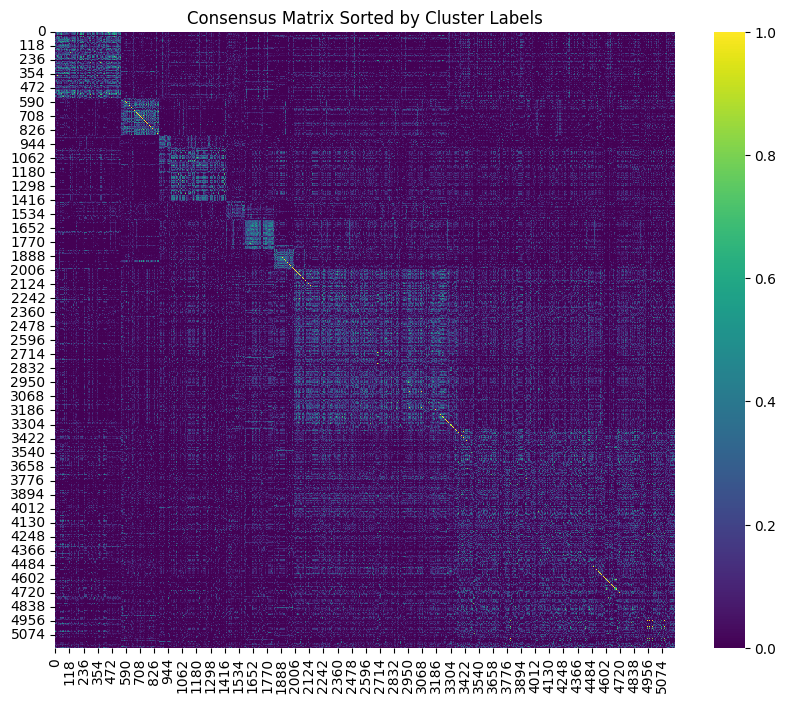

In [10]:
order = np.argsort(consensus_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(coassign[order][:, order], cmap="viridis")
plt.title("Consensus Matrix Sorted by Cluster Labels")
plt.show()


In [11]:
strength = {}

for k in consensus_labels:
    idx = np.where(consensus_labels == k)[0]
    sub = coassign[np.ix_(idx, idx)]
    vals = sub[np.triu_indices(len(idx), k=1)]
    strength[k] = vals.mean()

strength


{8: 0.1369577175735043,
 9: 0.09168234687581744,
 6: 0.27150331586271975,
 7: 0.25839843212034536,
 3: 0.221586366505365,
 4: 0.17762935760360737,
 5: 0.1530438740349914,
 1: 0.1788325891508064,
 2: 0.21398254266360592}

In [12]:
# keep only strong clusters
strong_clusters = [k for k, s in strength.items() if s > 0.20]
strong_clusters


[6, 7, 3, 2]

In [13]:
# Build gene universe (Entrez IDs) from GO_BP and map to consensus clusters

# We assume the clustering rows are in the same order as GO_BP rows
# (this is how the co-assignment was built across views)

# 1) Gene list as Entrez IDs from GO_BP index
genes = GO_BP.index.astype(str).tolist()

# 2) Sanity checks: clustering tables must have same number of rows
n_rows = len(genes)
for view_name, df in clusterings.items():
    assert df.shape[0] == n_rows, f"Row mismatch: {view_name} has {df.shape[0]}, GO_BP has {n_rows}"

assert len(consensus_labels) == n_rows, (
    f"Consensus labels length {len(consensus_labels)} != number of genes {n_rows}"
)

print(f"Detected {n_rows} Entrez IDs from GO_BP index.")

# 3) Map consensus cluster ID -> list of Entrez IDs
clusters_genes = {}
for cid in np.unique(consensus_labels):
    idx = np.where(consensus_labels == cid)[0]
    clusters_genes[int(cid)] = [genes[i] for i in idx]

# 4) Define universe as all measured genes
universe_genes = genes

# Quick summary per cluster
{cid: len(glist) for cid, glist in clusters_genes.items()}

Detected 5183 Entrez IDs from GO_BP index.


{1: 554, 2: 314, 3: 98, 4: 458, 5: 162, 6: 239, 7: 175, 8: 1343, 9: 1840}

In [22]:
# Initialize g:Profiler client (returns pandas DataFrame)
gp = GProfiler(return_dataframe=True)

# Choose sources; tweak as needed
sources = ["GO:BP", "GO:MF", "GO:CC", "REAC", "KEGG", "HP"]

all_results = []
for cid, gene_list in clusters_genes.items():
    # skip tiny clusters
    if len(gene_list) < 3:
        continue
    try:
        res = gp.profile(
            organism="hsapiens",                    # adjust if not human
            query=gene_list,                         # genes in the cluster
            background=universe_genes,               # custom background (all genes measured)
            sources=sources,
        )
    except Exception as e:
        print(f"Cluster {cid}: enrichment failed: {e}")
        res = None

    if res is not None and len(res) > 0:
        res["cluster_id"] = cid
        res["cluster_size"] = len(gene_list)
        # -log10(FDR) for plotting
        if "p_value" in res.columns:
            res["neglog10_p"] = -np.log10(res["p_value"].clip(lower=1e-300))
        all_results.append(res)
    else:
        print(f"Cluster {cid}: no significant terms (check gene IDs / organism).")

if len(all_results) > 0:
    enr_df = pd.concat(all_results, ignore_index=True)
    # Sort within cluster by adjusted p-value
    if "p_value" in enr_df.columns:
        enr_df = enr_df.sort_values(["cluster_id", "p_value"], ascending=[True, True])

    # Summary: how many hits per cluster
    print("Significant terms per cluster:")
    print(enr_df.groupby("cluster_id").size())

    # Show top N terms per cluster instead of a global head()
    N = 5
    top_per_cluster = (
        enr_df
        .sort_values(["cluster_id", "p_value"], ascending=[True, True])
        .groupby("cluster_id", group_keys=False)
        .head(N)
    )

    # Pick the correct term column for display
    term_col = "term_name" if "term_name" in top_per_cluster.columns else ("name" if "name" in top_per_cluster.columns else None)
    if term_col is None:
        display(top_per_cluster.head(10))
    else:
        display(top_per_cluster[["cluster_id", term_col, "source", "p_value", "neglog10_p", "query_size", "intersection_size"]].head(50))
else:
    print("No enrichment results across clusters.")

Significant terms per cluster:
cluster_id
1    1188
2     869
3    1179
4    1045
5    1185
6    1158
7     261
8     160
9    1017
dtype: int64


,cluster_id,name,source,p_value,neglog10_p,query_size,intersection_size
0,1,transcription cis-regulatory region binding,GO:MF,4.940656e-324,300.000000,553,371
1,1,DNA-binding transcription factor activity,GO:MF,4.940656e-324,300.000000,553,348
2,1,double-stranded DNA binding,GO:MF,4.940656e-324,300.000000,553,384
3,1,transcription by RNA polymerase II,GO:BP,4.940656e-324,300.000000,553,477
4,1,DNA binding,GO:MF,4.940656e-324,300.000000,553,447
1188,2,monoatomic ion transmembrane transporter activity,GO:MF,1.571343e-234,233.803729,313,245
1189,2,monoatomic ion transmembrane transport,GO:BP,3.569801e-223,222.447356,313,256
1190,2,transmembrane transporter activity,GO:MF,3.924226e-215,214.406246,313,256
1191,2,inorganic molecular entity transmembrane trans...,GO:MF,3.066555e-212,211.513349,313,232
1192,2,monoatomic ion transport,GO:BP,4.646422e-212,211.332881,313,264


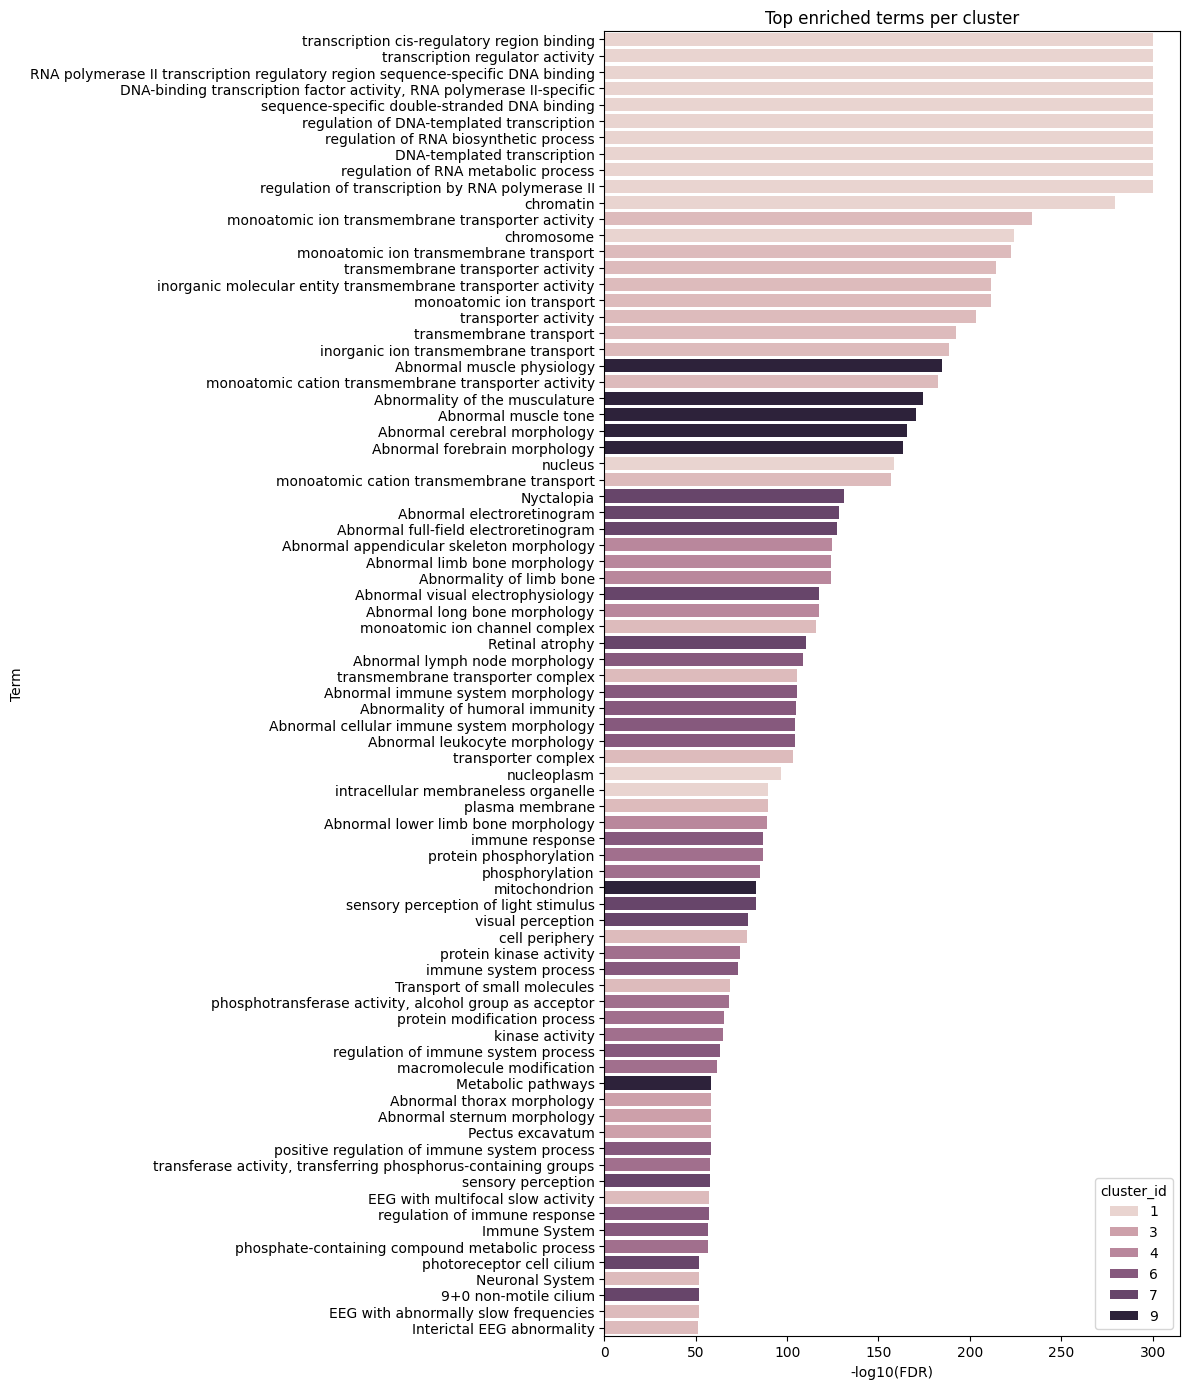

/var/folders/49/2vtyfv4n7cxb_hl_7_5wf97w0000gn/T/ipykernel_14141/3084167227.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: ", ".join(d.head(3)[term_col].tolist()))


In [20]:

if 'enr_df' in locals() and isinstance(enr_df, pd.DataFrame) and len(enr_df) > 0:
    # Pick the correct term column (g:Profiler versions differ)
    term_col = "term_name" if "term_name" in enr_df.columns else ("name" if "name" in enr_df.columns else None)
    if term_col is None:
        raise KeyError(f"No term column found. Available columns: {list(enr_df.columns)}")

    # Ensure plotting score exists
    if "neglog10_p" not in enr_df.columns and "p_value" in enr_df.columns:
        enr_df["neglog10_p"] = -np.log10(enr_df["p_value"].clip(lower=1e-300))

    # Plot: top 5 terms per source per cluster (by FDR)
    if "p_value" in enr_df.columns:
        top_df = (enr_df
                  .sort_values("p_value")
                  .groupby(["cluster_id", "source"], as_index=False)
                  .head(5))
        max_terms = min(80, len(top_df))
        plot_df = top_df.head(max_terms)

        plt.figure(figsize=(12, max(4, int(len(plot_df) * 0.18))))
        sns.barplot(data=plot_df, x="neglog10_p", y=term_col, hue="cluster_id", dodge=False)
        plt.xlabel("-log10(FDR)")
        plt.ylabel("Term")
        plt.title("Top enriched terms per cluster")
        plt.tight_layout()
        plt.show()

        # Also save condensed top terms per cluster table
        top_table = (top_df
                     .groupby(["cluster_id", "source"])
                     .apply(lambda d: ", ".join(d.head(3)[term_col].tolist()))
                     .reset_index(name="top_terms"))
else:
    print("No enrichment results to save or plot.")

In [28]:
# Select top GO:BP terms per consensus cluster
import pandas as pd
import numpy as np

if 'enr_df' not in locals() or not isinstance(enr_df, pd.DataFrame) or len(enr_df) == 0:
    raise RuntimeError("enr_df is missing or empty. Run the enrichment cell first.")

# Accept common GO:BP source labels across versions
bp_sources = {"GO:BP", "BP", "GOBP"}
df_bp = enr_df[enr_df["source"].isin(bp_sources)].copy()
if df_bp.empty:
    raise RuntimeError("No GO:BP terms found in enrichment results. Check sources or thresholds.")

# Robust term ID / name columns across gprofiler-official versions
id_col = "native" if "native" in df_bp.columns else ("term_id" if "term_id" in df_bp.columns else None)
name_col = "term_name" if "term_name" in df_bp.columns else ("name" if "name" in df_bp.columns else None)
if id_col is None:
    raise KeyError(f"No GO term ID column found in enrichment results. Columns: {list(df_bp.columns)}")
if name_col is None:
    raise KeyError(f"No GO term name column found in enrichment results. Columns: {list(df_bp.columns)}")

# Ensure plotting score exists
if "neglog10_p" not in df_bp.columns and "p_value" in df_bp.columns:
    df_bp["neglog10_p"] = -np.log10(df_bp["p_value"].clip(lower=1e-300))

# Take top-k terms per cluster by p-value, and keep the best cluster if a term appears in multiple clusters
top_k = 3
_top = (df_bp.sort_values(["cluster_id", "p_value"], ascending=[True, True])
             .groupby("cluster_id", group_keys=False)
             .head(top_k))
# Deduplicate by term ID keeping the row with lowest p-value across clusters
top_bp = _top.loc[_top.groupby(id_col)["p_value"].idxmin()].copy()

# Dictionaries for plotting
go_to_cluster = {row[id_col]: int(row["cluster_id"]) for _, row in top_bp.iterrows()}
go_to_score   = {row[id_col]: float(row.get("neglog10_p", 1.0)) for _, row in top_bp.iterrows()}  # significance (-log10 FDR)
go_to_name    = {row[id_col]: str(row[name_col]) for _, row in top_bp.iterrows()}
# Term frequency in the query: use intersection_size when available
go_to_freq    = {row[id_col]: int(row.get("intersection_size", 1)) for _, row in top_bp.iterrows()}

print(f"Selected {len(top_bp)} GO:BP terms across {top_bp['cluster_id'].nunique()} clusters (top {top_k} per cluster).")

Selected 27 GO:BP terms across 9 clusters (top 3 per cluster).


In [29]:
# Load GO DAG (go-basic.obo) via obonet
import os

try:
    import obonet
    import networkx as nx
except ImportError as e:
    raise ImportError("Missing packages. Install with: pip install obonet networkx")

obo_path = os.path.join("data", "go-basic.obo")
if os.path.exists(obo_path):
    G = obonet.read_obo(obo_path)
else:
    # Download from the official URL and cache in data/
    url = "https://purl.obolibrary.org/obo/go/go-basic.obo"
    os.makedirs("data", exist_ok=True)
    try:
        import urllib.request
        print("Downloading go-basic.obo ...")
        urllib.request.urlretrieve(url, obo_path)
        G = obonet.read_obo(obo_path)
        print(f"Loaded GO DAG with {G.number_of_nodes()} terms, cached at {obo_path}")
    except Exception as ex:
        print("Failed to download go-basic.obo; attempting to read from URL directly.")
        G = obonet.read_obo(url)
        print(f"Loaded GO DAG with {G.number_of_nodes()} terms from URL")

# Keep only Biological Process namespace for clarity
bp_nodes = {n for n, d in G.nodes(data=True) if d.get("namespace") == "biological_process"}
G_bp = G.subgraph(bp_nodes).copy()

print(f"GO:BP subgraph has {G_bp.number_of_nodes()} nodes and {G_bp.number_of_edges()} edges.")

GO:BP subgraph has 25153 nodes and 55809 edges.


/var/folders/49/2vtyfv4n7cxb_hl_7_5wf97w0000gn/T/ipykernel_14141/2340898098.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(10, len(clusters_present)))


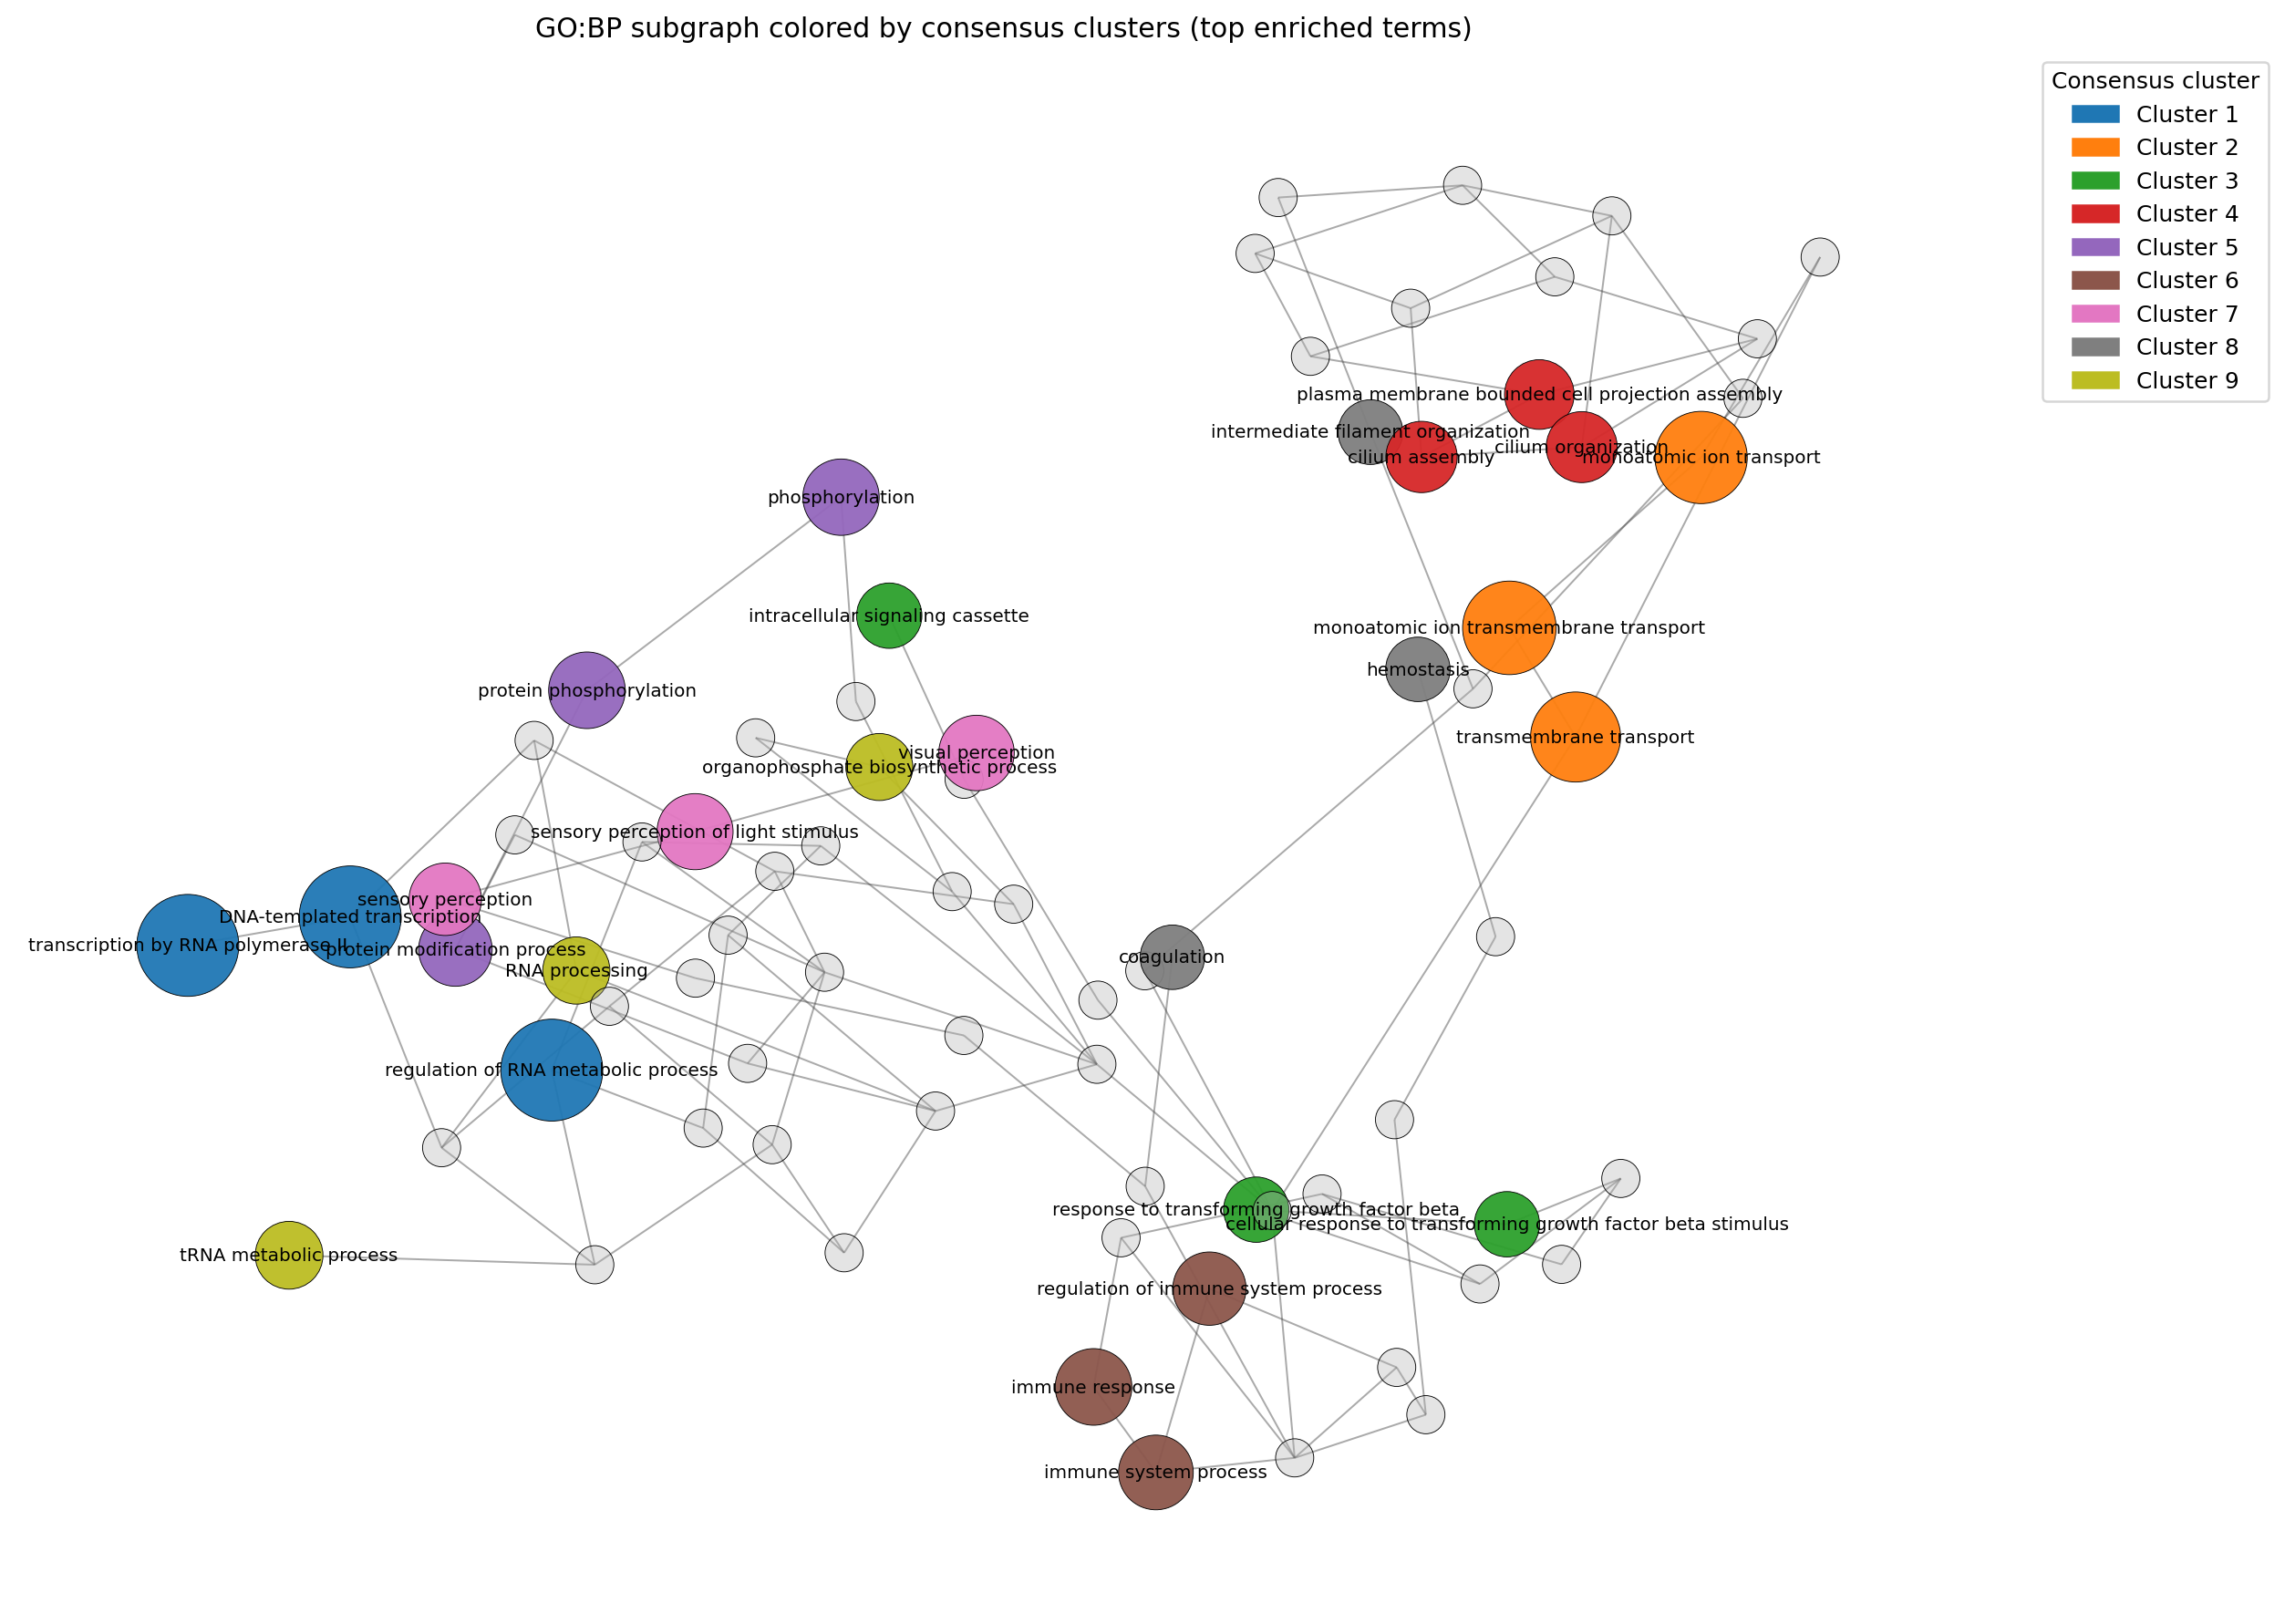

In [32]:
# Plot a GO:BP subgraph colored by consensus cluster (readable, sized by metric)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Selected GO term IDs
selected_ids = list(go_to_cluster.keys())

# Parameters
size_metric = 'significance'  # 'significance' | 'frequency' | 'hybrid'
min_size, max_size = 800.0, 2000.0
label_mode = 'all'            # 'all' | 'topN' | 'none'
label_limit = 60              # used if label_mode in {'all','topN'}
anc_depth = 2                 # ancestor depth to connect selected terms

# Gather ancestors up to a limited depth to connect the selected terms
nodes_keep = set(selected_ids)
frontier = set(selected_ids)
for _ in range(anc_depth):
    next_frontier = set()
    for node in frontier:
        if node in G_bp:
            parents = [v for _, v in G_bp.out_edges(node)]  # child -> parent in OBO
            for p in parents:
                nodes_keep.add(p)
                next_frontier.add(p)
    frontier = next_frontier

S = G_bp.subgraph(nodes_keep).copy()

# Prune leaf ancestors (not selected terms) to reduce clutter
for _ in range(2):  # up to two pruning passes
    leaf_ancestors = [n for n in list(S.nodes()) if n not in selected_ids and S.degree(n) <= 1]
    if not leaf_ancestors:
        break
    S.remove_nodes_from(leaf_ancestors)

# Colors for clusters (handles 9 clusters with tab10)
clusters_present = sorted({go_to_cluster[g] for g in selected_ids})
cmap = plt.cm.get_cmap('tab10', max(10, len(clusters_present)))
cluster_to_color = {cid: cmap(i % 10) for i, cid in enumerate(clusters_present)}

# Helper to get size metric value per selected node
def metric_value(n):
    if size_metric == 'frequency':
        return float(go_to_freq.get(n, 1))
    elif size_metric == 'hybrid':
        sig = float(go_to_score.get(n, 1.0))
        freq = float(go_to_freq.get(n, 1))
        return sig * np.log2(1.0 + freq)
    else:  # 'significance'
        return float(go_to_score.get(n, 1.0))

# Collect metric values only for selected nodes
metric_vals = np.array([metric_value(n) for n in selected_ids], dtype=float)
# Normalize to [min_size, max_size]
if np.allclose(metric_vals.min(), metric_vals.max()):
    # If all equal, use mid-size to avoid flat visuals
    norm_sizes = np.full_like(metric_vals, (min_size + max_size) / 2.0)
else:
    vmin, vmax = metric_vals.min(), metric_vals.max()
    norm_sizes = min_size + (metric_vals - vmin) / (vmax - vmin) * (max_size - min_size)
size_map = {n: s for n, s in zip(selected_ids, norm_sizes)}

# Node attributes for plotting (semi-transparent ancestors)
node_colors = []
node_sizes = []
labels = {}
for n in S.nodes():
    if n in go_to_cluster:
        base_rgba = cluster_to_color[go_to_cluster[n]]
        c = (base_rgba[0], base_rgba[1], base_rgba[2], 0.95)
        s = float(size_map.get(n, (min_size + max_size) / 2.0))
    else:
        c = (0.7, 0.7, 0.7, 0.35)  # ancestor nodes: light grey, more transparent
        s = min_size * 0.35
    node_colors.append(c)
    node_sizes.append(s)
    labels[n] = go_to_name.get(n, G_bp.nodes[n].get('name', n))

# Layout and draw (wider spacing, edges first)
plt.figure(figsize=(14, 10), dpi=180)
pos = nx.spring_layout(S, seed=42, k=1.2, iterations=300)

nx.draw_networkx_edges(S, pos, width=0.8, alpha=0.45, edge_color="#444", arrows=False)
nx.draw_networkx_nodes(S, pos, node_color=node_colors, node_size=node_sizes, edgecolors='k', linewidths=0.35)

# Labels
if label_mode == 'none':
    pass
else:
    if label_mode == 'topN':
        # label the top-N by metric
        order_nodes = sorted(selected_ids, key=lambda n: metric_value(n), reverse=True)
        label_nodes = order_nodes[:min(label_limit, len(order_nodes))]
    else:  # 'all'
        label_nodes = selected_ids[:min(label_limit, len(selected_ids))]
    sel_labels = {n: labels[n] for n in label_nodes if n in S}
    nx.draw_networkx_labels(S, pos, labels=sel_labels, font_size=8)

# Legend
handles = [mpatches.Patch(color=cluster_to_color[cid], label=f"Cluster {cid}") for cid in clusters_present]
plt.legend(handles=handles, title="Consensus cluster", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.axis('off')
plt.title('GO:BP subgraph colored by consensus clusters (top enriched terms)')
plt.tight_layout()
plt.show()
